# 23_01 — Datos reales y preprocesamiento · Río Mapocho en Los Almendros

Paso **1 de 5** del ciclo `Python → MATLAB → Python`, con la arquitectura de la corrida 50 aplicada a una
serie **observada** en vez de a un generador:




## 1. Imports y rutas

In [9]:
import json
import math
import sys
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Contrato de artefactos: mismos escritores que en simulación
from model_psbp_fd.pipelines import (
    guardar_curvas, guardar_representacion, guardar_fpca,
    guardar_estandarizador, guardar_datasets_ar,
    guardar_hiperparametros, guardar_config_evaluacion,
    verificar_contrato,
)
# Preprocesamiento funcional
from model_psbp_fd.functions_models import (
    FunctionalRepresentation, FPCA_L2, base_en_grilla, DataStandardizer,
)
from model_psbp_fd.fit import tabla_baselines
# Rutas del contrato: el gemelo Python de config_paths.m.
from model_psbp_fd.utils import (
    get_project_root, normalizar_lista_M, construir_paths,
    guardar_en_todos, replicar_figura,
)
from model_psbp_fd.graphics import (
    plot_empirical_sample, plot_mean_and_variance, plot_fts_empirical,
    plot_fts_functional, plot_diagnostico_estandarizacion, plot_fpca_scree,
    plot_seleccion_basis, plot_rezagos_heatmap,
)

plt.style.use("seaborn-v0_8-darkgrid")
%matplotlib inline

### 1.1 `[CONFIG]` Identificación del experimento y barrido en $M$

In [10]:
PROJECT_ROOT = get_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# [CONFIG] debe coincidir con 23_03, 23_04, 23_05 y con psbp_fd_iteracion.m
BASENAME     = "real"
SERIE_ID     = "nivel"    # variable modelada; ver VARIABLE en §2.1
VENTANA_ID   = 4          # etiqueta de la corrida; cambiarla NO pisa artefactos previos
SEED         = 41232      # semilla base; MATLAB la LEE de hyperparameters.json

# [BARRIDO] componentes FPCA retenidas: elegir mirando la varianza acumulada de §3.3.
# Debe ser el mismo en los cuatro notebooks y en el .m.
M_FPCA_LIST = (1, 2, 3)

LIMPIAR_DIRECTORIOS = True

M_FPCA_LIST     = normalizar_lista_M(M_FPCA_LIST)
EXPERIMENT_BASE = f"{BASENAME}_{SERIE_ID}_v{VENTANA_ID:02d}"


def eid_de(M: int) -> str:
    """real_<serie>_v<ventana a 2 digitos>_m<M a 2 digitos>"""
    return f"{EXPERIMENT_BASE}_m{int(M):02d}"


print(f"PROJECT_ROOT    : {PROJECT_ROOT}")
print(f"EXPERIMENT_BASE : {EXPERIMENT_BASE}")
print(f"serie {SERIE_ID} · ventana {VENTANA_ID} · seed base {SEED}")
print(f"barrido en M    : {list(M_FPCA_LIST)}")
for _M in M_FPCA_LIST:
    print(f"   M={_M}  ->  {eid_de(_M)}")


PROJECT_ROOT    : C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1
EXPERIMENT_BASE : real_nivel_v04
serie nivel · ventana 4 · seed base 41232
barrido en M    : [1, 2, 3]
   M=1  ->  real_nivel_v04_m01
   M=2  ->  real_nivel_v04_m02
   M=3  ->  real_nivel_v04_m03


In [11]:
PATHS_POR_M = {M: construir_paths(eid_de(M), dominio="reales",
                                  project_root=PROJECT_ROOT,
                                  limpiar=LIMPIAR_DIRECTORIOS)
               for M in M_FPCA_LIST}

for M, p in PATHS_POR_M.items():
    print(f"M={M}  ({eid_de(M)})")
    for nombre, ruta in p.items():
        print(f"  {nombre:12s} -> {ruta}")


M=1  (real_nivel_v04_m01)
  raw          -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\reales\raw\real_nivel_v04_m01
  functional   -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\reales\processed\functional\real_nivel_v04_m01
  predict      -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\reales\processed\predict\real_nivel_v04_m01
  out_report   -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\reales\real_nivel_v04_m01
  out_artefact -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\artefact\reales\real_nivel_v04_m01
M=2  (real_nivel_v04_m02)
  raw          -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\reales\raw\real_nivel_v04_m02
  functional   -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\reales\processed\functional\real_nivel_v04_m02
  predict      -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\reales\processed\predict\re

## 2. Datos

### 2.1 `[CONFIG]` Fuente, variable y rango de fechas

La estación entrega 48 mediciones diarias (cada media hora). Cada **día** es una curva $X_t(\tau)$ sobre el dominio intra-diario normalizado a $[0, 1]$, y $t$ recorre los días: ésa es la serie de tiempo funcional.

`FECHA_INICIO` y `FECHA_FIN` (ambas inclusivas) fijan el rango. $T$ **no se declara**: es el número de días completos que quedan en el rango tras descartar los incompletos. `PROP_TRAIN` se mantiene en el valor del estudio.


In [12]:
ARCHIVO_EXCEL = (PROJECT_ROOT / "data" / "reales" / "raw"
                 / "Tabla_de_Mediciones_Wed_Jun_17_2026.xlsx")

# Las 6 primeras filas del archivo son metadatos de la estación, no datos.
FILAS_METADATOS = 6
COLUMNAS = ["Fecha", "Nivel de Agua (m)", "Turbiedad (NTU)",
            "Pptacion Inst (mm)", "Caudal (m3/seg)"]

VARIABLE = "Nivel de Agua (m)"   # <- serie modelada; coherente con SERIE_ID

# -- Rango de fechas ----------------------------------------------------------

FECHA_INICIO = "2022-01-01"
FECHA_FIN    = "2026-05-31"      # inclusiva; None = ultimo dia del archivo
PROP_TRAIN   = 0.70              # T0 = floor(PROP_TRAIN * T)

# -- Esquema de observacion ---------------------------------------------------
ANCLA_CONTINUIDAD = True
MAX_HUECO_DIA     = 0.20         # dias con mas del 20 % ausente se descartan

print(f"archivo   : {ARCHIVO_EXCEL.name}")
print(f"variable  : {VARIABLE}")
print(f"rango     : {FECHA_INICIO}  ...  {FECHA_FIN or 'fin del archivo'}")
assert ARCHIVO_EXCEL.exists(), f"No se encontro el Excel en {ARCHIVO_EXCEL}"


archivo   : Tabla_de_Mediciones_Wed_Jun_17_2026.xlsx
variable  : Nivel de Agua (m)
rango     : 2022-01-01  ...  2026-05-31


### 2.2 Lectura, pivoteo y control de calidad

Aquí está todo lo que un generador simulado da gratis y una serie observada no:
huecos, días incompletos, marcas de tiempo duplicadas y orden de las fechas. Se
comprueba explícitamente en vez de confiar en que el archivo esté bien, porque
cada uno de esos problemas produce curvas plausibles y resultados falsos.

In [13]:
df = pd.read_excel(
    ARCHIVO_EXCEL,
    skiprows=FILAS_METADATOS,
    names=COLUMNAS,
    header=None,
    parse_dates=["Fecha"],
    date_format="%d/%m/%Y %H:%M",   # dd/mm: sin esto el 03/04 se lee como abril 3
)
df = df.sort_values("Fecha").reset_index(drop=True)
assert VARIABLE in df.columns, f"{VARIABLE!r} no esta en {list(df.columns)}"

print(f"filas leidas : {len(df)}")
print(f"cobertura    : {df['Fecha'].min()}  ...  {df['Fecha'].max()}")
print(f"faltantes en {VARIABLE}: {int(df[VARIABLE].isna().sum())}")

# -- Ventana [FECHA_INICIO, FECHA_FIN], mas el dia-ancla previo ---------------
_ini   = pd.Timestamp(FECHA_INICIO)
_fin   = (pd.Timestamp(FECHA_FIN) + pd.Timedelta(days=1) if FECHA_FIN is not None
          else df["Fecha"].max().normalize() + pd.Timedelta(days=1))   # limite exclusivo
assert _fin > _ini, f"FECHA_FIN ({FECHA_FIN}) debe ser posterior a FECHA_INICIO ({FECHA_INICIO})."
_desde = _ini - pd.Timedelta(days=1) if ANCLA_CONTINUIDAD else _ini
_v     = df.loc[(df["Fecha"] >= _desde) & (df["Fecha"] < _fin)].copy()
assert len(_v) > 0, f"El rango [{_desde}, {_fin}) no contiene datos."

_v["Dia"]  = _v["Fecha"].dt.date
_v["Hora"] = _v["Fecha"].dt.time

# -- Duplicados de (dia, hora) --------------------------------------------------
# `pivot` falla ante duplicados; `pivot_table` los promedia en silencio. Se
# cuentan antes para que la decision sea visible.
_dup = int(_v.duplicated(subset=["Dia", "Hora"]).sum())
print(f"\nmarcas (dia, hora) duplicadas: {_dup}" + ("   <- promediadas" if _dup else ""))

matriz = _v.pivot_table(index="Dia", columns="Hora", values=VARIABLE, aggfunc="mean")

# -- Grilla intra-diaria canonica -----------------------------------------------
# Se retienen las horas presentes en al menos el 90 % de los dias y se
# reindexa, de modo que TODOS los dias compartan exactamente la misma grilla.
_cob_hora = matriz.notna().mean(axis=0)
_horas_ok = _cob_hora[_cob_hora >= 0.90].index
print(f"horas distintas observadas: {matriz.shape[1]}   "
      f"retenidas (>=90 % de dias): {len(_horas_ok)}")
matriz = matriz.reindex(columns=_horas_ok).sort_index(axis=1)

# -- Huecos aislados -----------------------------------------------------------
# Se interpola DENTRO de cada dia (a lo largo de tau): un hueco de media hora se
# parece mas a sus vecinos del mismo dia que al promedio de esa hora en cientos
# de dias distintos.
_na_antes   = int(matriz.isna().sum().sum())
_frac_dia   = matriz.isna().mean(axis=1)
_dias_malos = _frac_dia[_frac_dia > MAX_HUECO_DIA].index
matriz = matriz.drop(index=_dias_malos)
matriz = matriz.interpolate(axis=1, limit_direction="both")

print(f"celdas ausentes: {_na_antes}  ({_na_antes / max(matriz.size, 1):.3%})")
print(f"dias descartados por >{MAX_HUECO_DIA:.0%} ausente: {len(_dias_malos)}"
      + (f"  {[str(d) for d in _dias_malos[:5]]}" if len(_dias_malos) else ""))
assert not matriz.isna().any().any(), "Quedan NaN tras la interpolacion."


filas leidas : 106162
cobertura    : 2020-01-01 00:14:00  ...  2026-05-31 23:44:00
faltantes en Nivel de Agua (m): 43

marcas (dia, hora) duplicadas: 0
horas distintas observadas: 48   retenidas (>=90 % de dias): 48
celdas ausentes: 1697  (2.338%)
dias descartados por >20% ausente: 37  ['2022-01-05', '2022-01-07', '2022-01-08', '2022-01-09', '2022-01-10']


In [14]:
# -- Ancla de continuidad ------------------------------------------------------
if ANCLA_CONTINUIDAD:
    ancla = matriz.iloc[:, -1].shift(1)      # ultima medicion del dia previo
    matriz.insert(0, "t0_prev", ancla)
    matriz = matriz.iloc[1:]                  # el primer dia no tiene ancla
    assert not matriz.isna().any().any(), "El ancla dejo NaN."

# -- Solo los dias DENTRO del rango pedido (el ancla previo ya cumplio su papel) --
_idx_dias = pd.to_datetime(pd.Series(matriz.index))
matriz = matriz.loc[(_idx_dias >= _ini).to_numpy() & (_idx_dias < _fin).to_numpy()]
assert len(matriz) > 20, f"Solo {len(matriz)} dias utilizables en el rango: amplie las fechas."

# -- Continuidad temporal de la serie FINAL ------------------------------------
# Un dia ausente rompe el supuesto AR: el rezago de t deja de ser t-1 en tiempo
# real. Se reporta y queda en el artefacto; NO se rellena inventando curvas.
_idx    = pd.to_datetime(pd.Series(matriz.index))
_saltos = int(((_idx.diff().dt.days.dropna()) != 1).sum())
print(f"saltos en la secuencia de dias modelados: {_saltos}"
      + ("   <- el rezago 1 no siempre es el dia anterior; declararlo al reportar"
         if _saltos else "   (serie diaria continua)"))

X_raw  = matriz.to_numpy(dtype=float)         # (T, G) curvas OBSERVADAS
T, G   = X_raw.shape
grilla = np.linspace(0.0, 1.0, G)             # tau_1 = 0 ... tau_G = 1
DIAS   = pd.to_datetime(pd.Series(matriz.index)).to_numpy()

print(f"curvas   : X_raw {X_raw.shape}   (T={T} dias, G={G} puntos por dia)")
print(f"periodo  : {pd.Timestamp(DIAS[0]).date()}  ...  {pd.Timestamp(DIAS[-1]).date()}")
print(f"particion: T0 = {int(np.floor(PROP_TRAIN * T))}, test = {T - int(np.floor(PROP_TRAIN * T))}")
print(f"rango de {VARIABLE}: [{X_raw.min():.3f}, {X_raw.max():.3f}]  "
      f"media {X_raw.mean():.3f}")

# -- Diagnostico de la serie -------------------------------------------------------
_nivel = X_raw.mean(axis=1)
_acf1  = float(np.corrcoef(_nivel[:-1], _nivel[1:])[0, 1])
diagnostico = {
    "T": int(T), "G": int(G),
    "acf1_nivel_diario":      round(_acf1, 6),
    "sd_entre_dias":          round(float(_nivel.std(ddof=1)), 6),
    "sd_intra_dia_media":     round(float(X_raw.std(axis=1, ddof=1).mean()), 6),
    "razon_intra_entre":      round(float(X_raw.std(axis=1, ddof=1).mean() / _nivel.std(ddof=1)), 6),
    "asimetria_nivel":        round(float(pd.Series(_nivel).skew()), 6),
    "exceso_curtosis_nivel":  round(float(pd.Series(_nivel).kurt()), 6),
    "dias_descartados":       int(len(_dias_malos)),
    "saltos_secuencia_dias":  int(_saltos),
    "duplicados_dia_hora":    int(_dup),
}
print("\nDiagnostico de la serie observada:")
for k, v in diagnostico.items():
    print(f"  {k:24s} = {v}")


saltos en la secuencia de dias modelados: 19   <- el rezago 1 no siempre es el dia anterior; declararlo al reportar
curvas   : X_raw (1511, 49)   (T=1511 dias, G=49 puntos por dia)
periodo  : 2022-01-01  ...  2026-05-31
particion: T0 = 1057, test = 454
rango de Nivel de Agua (m): [0.550, 2.734]  media 0.961

Diagnostico de la serie observada:
  T                        = 1511
  G                        = 49
  acf1_nivel_diario        = 0.988058
  sd_entre_dias            = 0.217724
  sd_intra_dia_media       = 0.018061
  razon_intra_entre        = 0.082953
  asimetria_nivel          = 0.783686
  exceso_curtosis_nivel    = 1.692729
  dias_descartados         = 37
  saltos_secuencia_dias    = 19
  duplicados_dia_hora      = 0


### 2.3 Visualización de la serie funcional

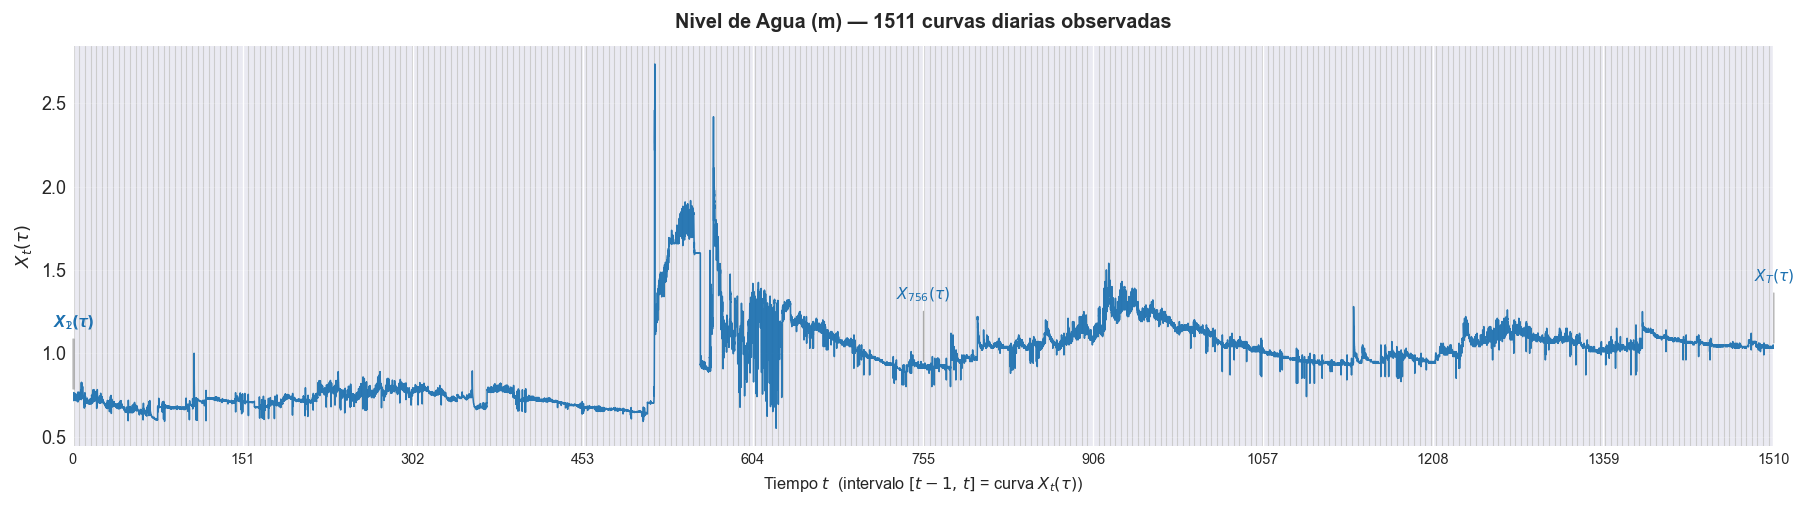

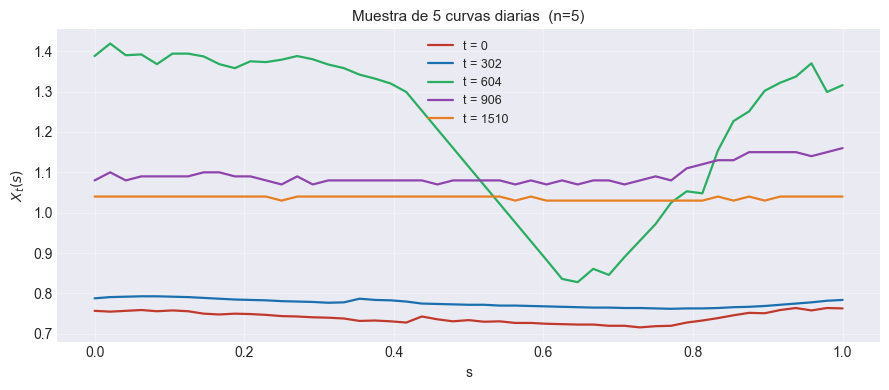

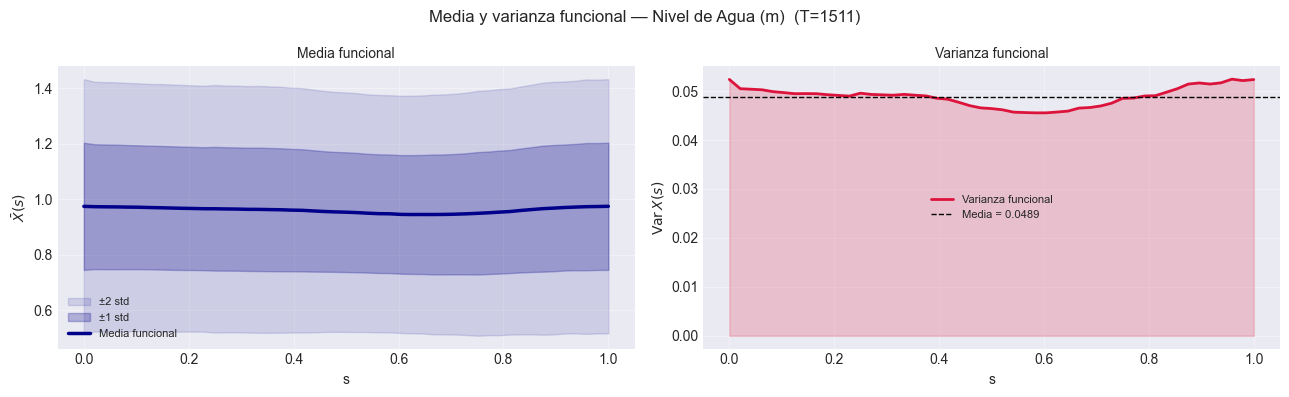

In [15]:
highlight_idx = [0, 1, T // 2, T - 1]

plot_fts_empirical(
    X_raw, grilla, highlight_idx=highlight_idx, separator_every=5,
    title=f"{VARIABLE} — {T} curvas diarias observadas")
replicar_figura("01_fts_empirica_raw.png", PATHS_POR_M)
plt.show()

plot_empirical_sample(
    X_raw, grilla, sample_idx=[0, T // 5, 2 * T // 5, 3 * T // 5, T - 1],
    title="Muestra de 5 curvas diarias")
replicar_figura("02_muestra_empirica_raw.png", PATHS_POR_M)
plt.show()

plot_mean_and_variance(
    X_raw, grilla, show_std1=True, show_std2=True,
    title=f"Media y varianza funcional — {VARIABLE}")
replicar_figura("03_media_varianza_raw.png", PATHS_POR_M)
plt.show()

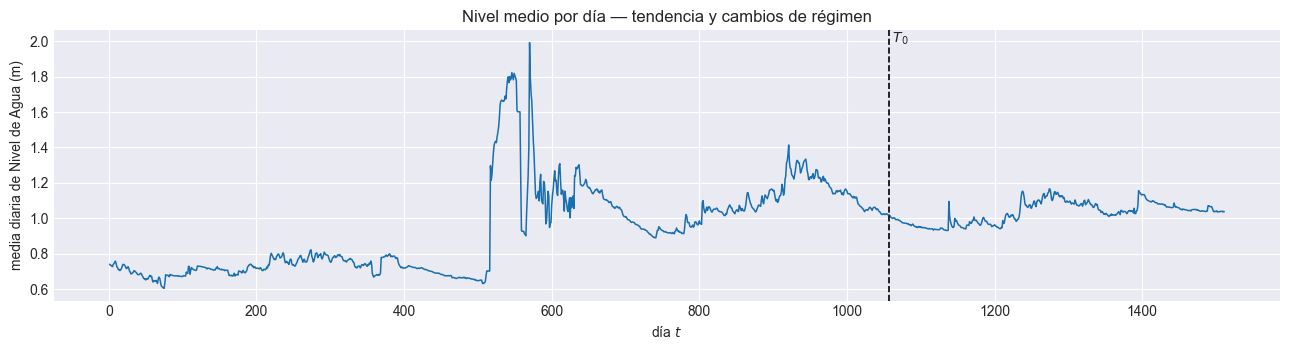

Media del nivel diario por tercio de la muestra:
  tercio 1: 0.7182  (sd 0.0442)
  tercio 2: 1.1302  (sd 0.2095)
  tercio 3: 1.0339  (sd 0.0579)

Una deriva marcada entre tercios significa que el bloque de prueba no es una
muestra de la misma ley que el de entrenamiento: declararlo al leer la caída en T0.


In [16]:
# Nivel diario en el tiempo, con el corte train/test marcado: dice si la serie
# tiene tendencia o cambios de regimen, que rompen la estacionariedad que los
# escenarios simulados imponen por construccion.
_T0_prev = int(np.floor(PROP_TRAIN * T))

fig, ax = plt.subplots(figsize=(13, 3.6))
ax.plot(np.arange(1, T + 1), _nivel, lw=1.1, color="#1a6faf")
ax.axvline(_T0_prev, color="k", ls="--", lw=1.2)
ax.text(_T0_prev, ax.get_ylim()[1], r" $T_0$", va="top", fontsize=10)
ax.set_xlabel("día $t$"); ax.set_ylabel(f"media diaria de {VARIABLE}")
ax.set_title("Nivel medio por día — tendencia y cambios de régimen")
fig.tight_layout()
replicar_figura("04_nivel_diario.png", PATHS_POR_M, fig=fig)
plt.show()

print("Media del nivel diario por tercio de la muestra:")
for i, tercio in enumerate(np.array_split(_nivel, 3), 1):
    print(f"  tercio {i}: {tercio.mean():.4f}  (sd {tercio.std(ddof=1):.4f})")
print("\nUna deriva marcada entre tercios significa que el bloque de prueba no es una\n"
      "muestra de la misma ley que el de entrenamiento: declararlo al leer la caída en T0.")


### 2.4 Persistencia de curvas

Sólo `X_curves.npy`: **no** hay `X_curves_true.npy` porque no hay curva sin ruido. Los notebooks `_04` y `_05` toman la observada como objetivo de evaluación.


In [17]:
_p = guardar_en_todos(guardar_curvas, PATHS_POR_M, X_raw, grilla)      # sin X_true: no existe
for clave, ruta in _p.items():
    print(f"[functional] {clave:12s} -> {ruta.name}   (replicado en {len(PATHS_POR_M)} directorios)")

# Análogo real de simulation_config.json. Lo lee 23_05 para documentar la fuente.
for _M, _p in PATHS_POR_M.items():
    dataset_config = {
        "fuente":        str(ARCHIVO_EXCEL),
        "estacion":      "RIO MAPOCHO EN LOS ALMENDROS",
        "variable":      VARIABLE,
        "serie_id":      SERIE_ID,
        "ventana_id":    int(VENTANA_ID),
        "fecha_inicio_pedida": FECHA_INICIO,
        "fecha_fin_pedida":    FECHA_FIN,
        "fecha_inicio":  str(pd.Timestamp(DIAS[0]).date()),
        "fecha_fin":     str(pd.Timestamp(DIAS[-1]).date()),
        "T": int(T), "G": int(G),
        "prop_train":    float(PROP_TRAIN),
        "ancla_continuidad": bool(ANCLA_CONTINUIDAD),
        "max_hueco_dia": float(MAX_HUECO_DIA),
        "diagnostico":   diagnostico,
        "experiment_id": eid_de(_M),
        "m_fpca":        int(_M),
        "m_fpca_list":   [int(m) for m in M_FPCA_LIST],
        "seed":          SEED,
        "procesado":     datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    }
    with open(_p["raw"] / "dataset_config.json", "w", encoding="utf-8") as f:
        json.dump(dataset_config, f, indent=2, ensure_ascii=False)
    # Los dias, para etiquetar cualquier figura por fecha aguas abajo.
    pd.Series(DIAS, name="dia").to_csv(_p["raw"] / "dias.csv", index=False)
    print(f"[raw · M={_M}] dataset_config.json · dias.csv")


[functional] curvas       -> X_curves.npy   (replicado en 3 directorios)
[functional] grilla       -> domain_grid.npy   (replicado en 3 directorios)
[raw · M=1] dataset_config.json · dias.csv
[raw · M=2] dataset_config.json · dias.csv
[raw · M=3] dataset_config.json · dias.csv


### 2.5 Partición temporal

Todo objeto **estimado a partir de los datos** —selección GCV de la base, FPCA,
estandarizador, que aquí queda en identidad— se ajusta sólo con $\{1,\dots,T_0\}$ y se aplica al bloque de
prueba mediante `transform`.

In [18]:
T0 = int(np.floor(PROP_TRAIN * T))
assert 10 < T0 < T, f"T0={T0} fuera de rango para T={T}."

idx_train, idx_test = np.arange(0, T0), np.arange(T0, T)
X, X_train, X_test = X_raw, X_raw[idx_train], X_raw[idx_test]

print(f"entrenamiento : t ∈ [1, {T0}]      → {X_train.shape}")
print(f"prueba        : t ∈ [{T0+1}, {T}]  → {X_test.shape}")
print(f"proporción    : {T0/T:.1%} / {1 - T0/T:.1%}")

entrenamiento : t ∈ [1, 1057]      → (1057, 49)
prueba        : t ∈ [1058, 1511]  → (454, 49)
proporción    : 70.0% / 30.0%


## 3. Representación funcional B-spline

### 3.1 Barrido GCV sobre `(n_basis, order)`

El GCV **sugiere**; la elección es del analista y se declara en 3.2.

,n_basis,order,var_retained,rmse_mean,rmse_max,gcv_mean
0,2,2,98.1374%,0.017299,0.339980,0.001318
1,3,2,98.8058%,0.013431,0.222330,0.000882
2,4,2,99.5797%,0.009215,0.211033,0.000324
3,5,2,99.5422%,0.009340,0.206101,0.000370
4,6,2,99.6822%,0.008173,0.201106,0.000269
5,7,2,99.7350%,0.007507,0.195025,0.000235
6,8,2,99.7655%,0.006997,0.189652,0.000218
7,9,2,99.8040%,0.006563,0.183769,0.000191
8,10,2,99.8125%,0.006321,0.177203,0.000193
9,11,2,99.8230%,0.006128,0.170296,0.000192



GCV mínimo → n_basis=18, order=4  (var retenida 99.9139%)


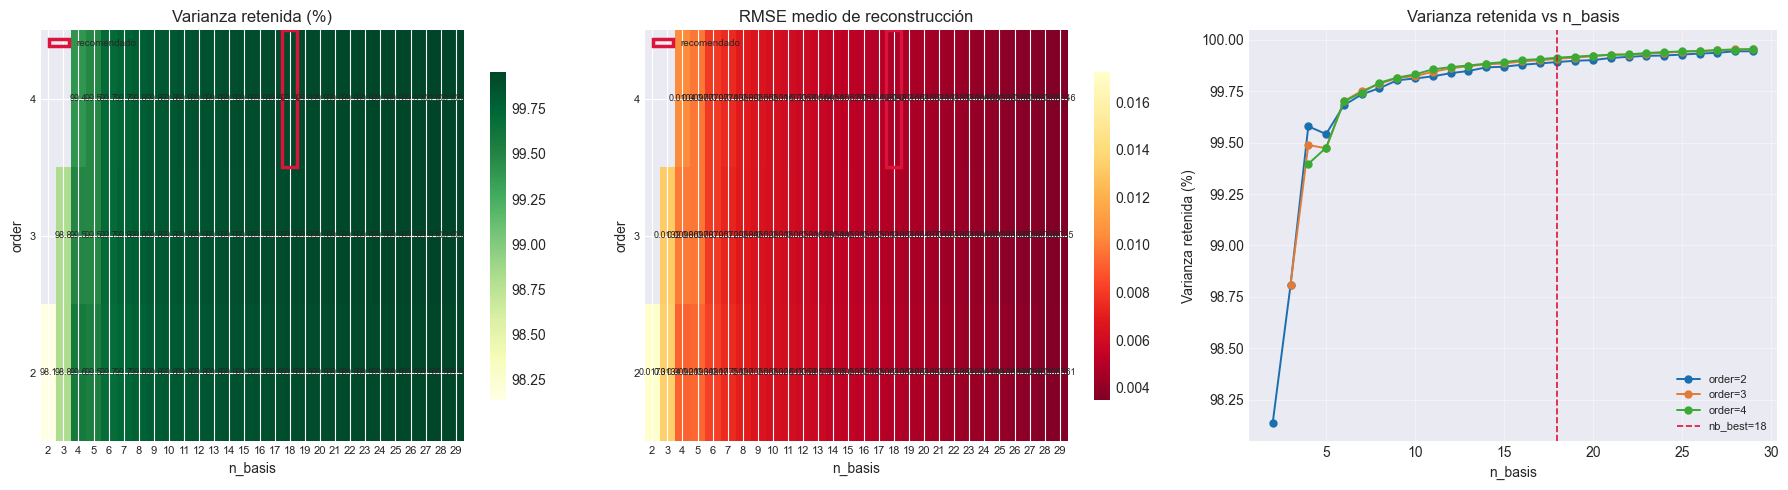

In [19]:
N_BASIS_RANGE = range(2, min(30, T0 // 2))   # acotado por T0
ORDER_RANGE   = range(2, 5)

registros = []
for orden in ORDER_RANGE:
    for nb in N_BASIS_RANGE:
        if nb < orden:
            continue
        try:
            fr_tmp = FunctionalRepresentation(method="bspline", n_basis=nb, order=orden)
            TH_tmp = fr_tmp.fit_transform(X_train, grilla)     # sólo train
            X_rec  = fr_tmp.reconstruct(TH_tmp)

            L_i    = X_train.shape[1]
            sse_c  = np.sum((X_train - X_rec) ** 2, axis=1)
            ss_tot = np.sum((X_train - X_train.mean(axis=0, keepdims=True)) ** 2)
            gcv_c  = (L_i * sse_c / (L_i - nb) ** 2 if L_i > nb
                      else np.full_like(sse_c, np.nan))
            registros.append({
                "n_basis": nb, "order": orden,
                "var_retained": 1.0 - sse_c.sum() / ss_tot,
                "rmse_mean": np.sqrt(sse_c / L_i).mean(),
                "rmse_max":  np.sqrt(sse_c / L_i).max(),
                "gcv_mean":  float(np.mean(gcv_c)),
            })
        except Exception as e:
            print(f"  [SKIP] n_basis={nb}, order={orden}: {e}")

sel_df   = pd.DataFrame(registros)
best_row = sel_df.dropna(subset=["gcv_mean"]).nsmallest(1, "gcv_mean").iloc[0]
nb_best, ord_best = int(best_row["n_basis"]), int(best_row["order"])

display(sel_df.style
    .format({"var_retained": "{:.4%}", "rmse_mean": "{:.6f}",
             "rmse_max": "{:.6f}", "gcv_mean": "{:.6f}"})
    .background_gradient(subset=["gcv_mean"], cmap="YlOrRd_r")
    .background_gradient(subset=["var_retained"], cmap="YlGn"))

print(f"\nGCV mínimo → n_basis={nb_best}, order={ord_best}  "
      f"(var retenida {best_row['var_retained']:.4%})")

plot_seleccion_basis(sel_df, nb_best, ord_best)
replicar_figura("05_seleccion_basis.png", PATHS_POR_M)
plt.show()

### 3.2 `[CONFIG]` Base elegida y ajuste

`center=False` es imprescindible: con `center=True` la reconstrucción es un
mapa **afín**, y la función media contaminaría la base recuperada por
`base_en_grilla`, la matriz de Gram y las autofunciones.

Base elegida : n_basis=18, order=4
Sugerido GCV : n_basis=18, order=4   (coinciden)
THETA (1511, 18)  (train=1057, test=454)


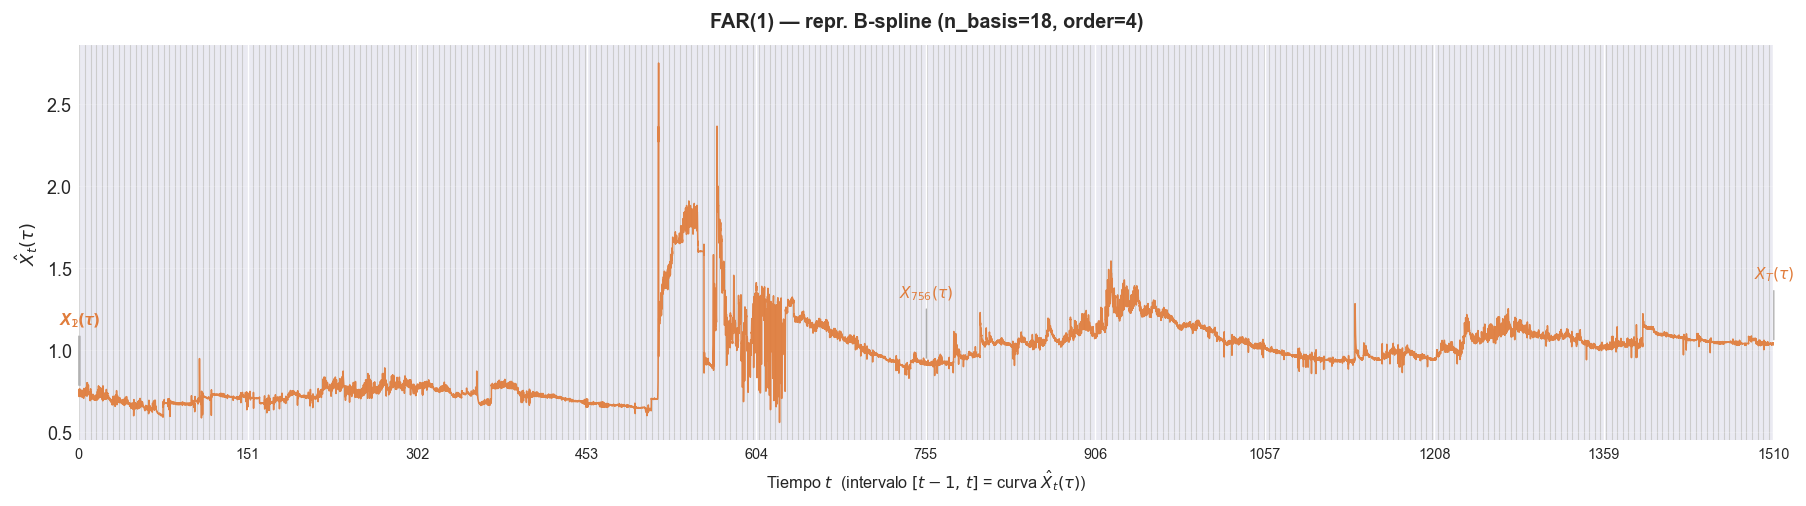

[functional] functional_representation.pkl + theta.csv + fr_config.json   (replicado en 3 directorios)


In [20]:
NB_ELEGIDO  = nb_best     # ← decisión del analista
ORD_ELEGIDO = ord_best

print(f"Base elegida : n_basis={NB_ELEGIDO}, order={ORD_ELEGIDO}")
print(f"Sugerido GCV : n_basis={nb_best}, order={ord_best}"
      + ("   (coinciden)" if (NB_ELEGIDO, ORD_ELEGIDO) == (nb_best, ord_best)
         else "   ← DIFIERE de la sugerencia; justificar en la tesis"))

fr = FunctionalRepresentation(method="bspline", n_basis=NB_ELEGIDO,
                              order=ORD_ELEGIDO, center=False)
fr.fit(X_train, grilla)                       # sólo train
THETA       = fr.transform(X, grilla)         # (T, K) serie completa
THETA_train = THETA[idx_train]
print(f"THETA {THETA.shape}  (train={T0}, test={T - T0})")

plot_fts_functional(
    X, grilla, fr=fr, highlight_idx=highlight_idx, separator_every=5,
    title=f"FAR(1) — repr. B-spline (n_basis={NB_ELEGIDO}, order={ORD_ELEGIDO})")
replicar_figura("06_fts_funcional_bspline.png", PATHS_POR_M)
plt.show()

guardar_en_todos(guardar_representacion, PATHS_POR_M, fr, THETA,
    extra={"T0": int(T0), "prop_train": float(PROP_TRAIN), "ajustado_en": "train",
           "center": bool(fr.center), "n_basis": int(NB_ELEGIDO),
           "order": int(ORD_ELEGIDO), "n_basis_gcv": nb_best, "order_gcv": ord_best})
print(f"[functional] functional_representation.pkl + theta.csv + fr_config.json"
      f"   (replicado en {len(PATHS_POR_M)} directorios)")

### 3.3 FPCA generalizado en $L^2$ y diagnóstico

In [21]:
Phi  = base_en_grilla(fr, THETA.shape[1])        # (G, K)
fpca = FPCA_L2().fit(THETA_train, Phi, grilla)

_ver = fpca.verificar(THETA_train, fr=fr)
print("Verificación FPCA_L2 (entrenamiento):")
for k, v in _ver.items():
    print(f"  {k:34s} = {v:.3e}" if isinstance(v, float) else f"  {k:34s} = {v}")

# cond(W) amplifica el ruido de las direcciones de menor autovalor, que son las
# que después se truncan. Se registra para comparar escenarios con distinto K.
cond = _ver["cond_W"]
nota = ("← MUY ALTO: reduzca n_basis" if cond > 1e10 else
        "← alto: vigile las componentes menores" if cond > 1e6 else "(sano)")
print(f"\ncond(W) = {cond:.3e}  {nota}")

assert _ver["todo_ok"], ("Las identidades del FPCA generalizado no se cumplen. "
                         "Si falla err_linealidad_reconstruct_rel, revise center=False.")

Verificación FPCA_L2 (entrenamiento):
  M                                  = 18
  K                                  = 18
  n_ajuste                           = 1057
  cond_W                             = 2.199e+01
  err_ortonormalidad_L2              = 3.331e-15
  err_ortonormalidad_gram            = 3.331e-15
  var_explicada                      = 1.000e+00
  err_rutas_reconstruccion           = 8.882e-16
  err_linealidad_reconstruct         = 0.000e+00
  err_linealidad_reconstruct_rel     = 0.000e+00
  err_media_scores                   = 2.828e-16
  err_media_scores_rel               = 5.771e-14
  err_var_scores_vs_lambda           = 1.388e-16
  err_var_scores_vs_lambda_rel       = 9.669e-13
  err_correlacion_lag0               = 7.885e-13
  criterios_evaluados                = ['err_ortonormalidad_L2', 'err_ortonormalidad_gram', 'err_rutas_reconstruccion', 'err_correlacion_lag0', 'err_linealidad_reconstruct_rel', 'err_media_scores_rel', 'err_var_scores_vs_lambda_rel']
  todo_ok   

,componente,autovalor,var_ratio,var_acum,ar1_propio
0,1,6.3113e-02,97.1209%,97.1209%,+0.988
1,2,1.1151e-03,1.7160%,98.8368%,+0.448
2,3,5.6138e-04,0.8639%,99.7007%,+0.359
3,4,5.9873e-05,0.0921%,99.7928%,+0.076
4,5,3.4658e-05,0.0533%,99.8461%,+0.185
5,6,2.4213e-05,0.0373%,99.8834%,-0.075
6,7,2.1883e-05,0.0337%,99.9171%,+0.169
7,8,1.2247e-05,0.0188%,99.9359%,+0.056
8,9,8.9427e-06,0.0138%,99.9497%,+0.117
9,10,7.4589e-06,0.0115%,99.9612%,+0.088



K disponibles: 18   ·   sugerencia (var ≥ 95%): M = 1
  M=1: var. acum = 97.1209%  ·  regla del 95 %
  M=2: var. acum = 98.8368%  ·  sensibilidad
  M=3: var. acum = 99.7007%  ·  sensibilidad


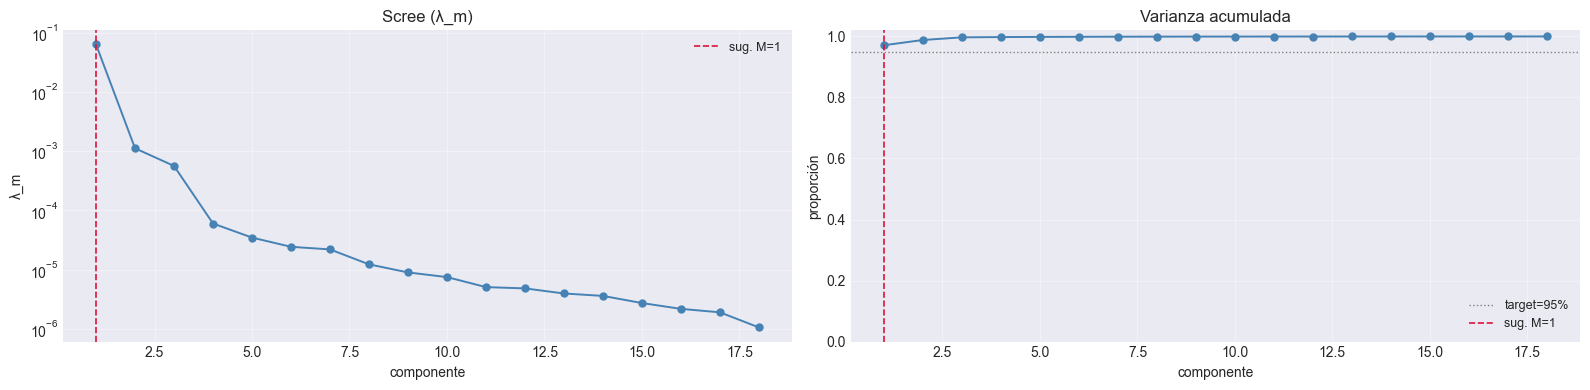

In [22]:
# Varianza ≠ dinámica: una FPC de varianza baja puede tener AR fuerte y ser útil
# para pronóstico, y una de varianza alta puede ser ruido temporal.
K   = fpca.evals.size
S_a = (THETA_train - fpca.mu_theta) @ (fpca.W @ fpca.B_full)     # (T0, K)
ar1 = (S_a[1:] * S_a[:-1]).sum(0) / np.clip((S_a[:-1] ** 2).sum(0), 1e-12, None)

VAR_TARGET  = 0.95
M_SUGERIDO  = fpca.seleccionar_M(VAR_TARGET)

display(pd.DataFrame({
    "componente": np.arange(1, K + 1), "autovalor": fpca.evals,
    "var_ratio": fpca.var_ratio, "var_acum": fpca.var_cum, "ar1_propio": ar1,
}).head(min(15, K)).style.format(
    {"autovalor": "{:.4e}", "var_ratio": "{:.4%}",
     "var_acum": "{:.4%}", "ar1_propio": "{:+.3f}"})
    .background_gradient(subset=["var_ratio"], cmap="YlGn")
    .background_gradient(subset=["ar1_propio"], cmap="coolwarm", vmin=-1, vmax=1))

print(f"\nK disponibles: {K}   ·   sugerencia (var ≥ {VAR_TARGET:.0%}): M = {M_SUGERIDO}")

# K lo fija el GCV y ACOTA el barrido
assert max(M_FPCA_LIST) <= K, (
    f"M_FPCA_LIST={list(M_FPCA_LIST)} excede el K disponible: la base elegida "
    f"(n_basis={NB_ELEGIDO}, order={ORD_ELEGIDO}) da K = {K} componentes. "
    f"Reduzca el barrido o elija una base con más funciones en §3.2.")

_frontera = max(3, int(np.ceil(0.75 * K)))
for _M in M_FPCA_LIST:
    _marca = "regla del 95 %" if _M == M_SUGERIDO else "sensibilidad"
    _aviso = ("   <- cerca del techo K: componente en buena medida artefacto "
              "de una base corta" if _M >= _frontera else "")
    print(f"  M={_M}: var. acum = {fpca.var_cum[_M-1]:.4%}  ·  {_marca}{_aviso}")

plot_fpca_scree(fpca.evals, fpca.var_cum, M_SUGERIDO, var_target=VAR_TARGET)
replicar_figura("07_fpca_scree.png", PATHS_POR_M)
plt.show()

### 3.4 Series de los componentes de la FPCA
- Se ven todos. 

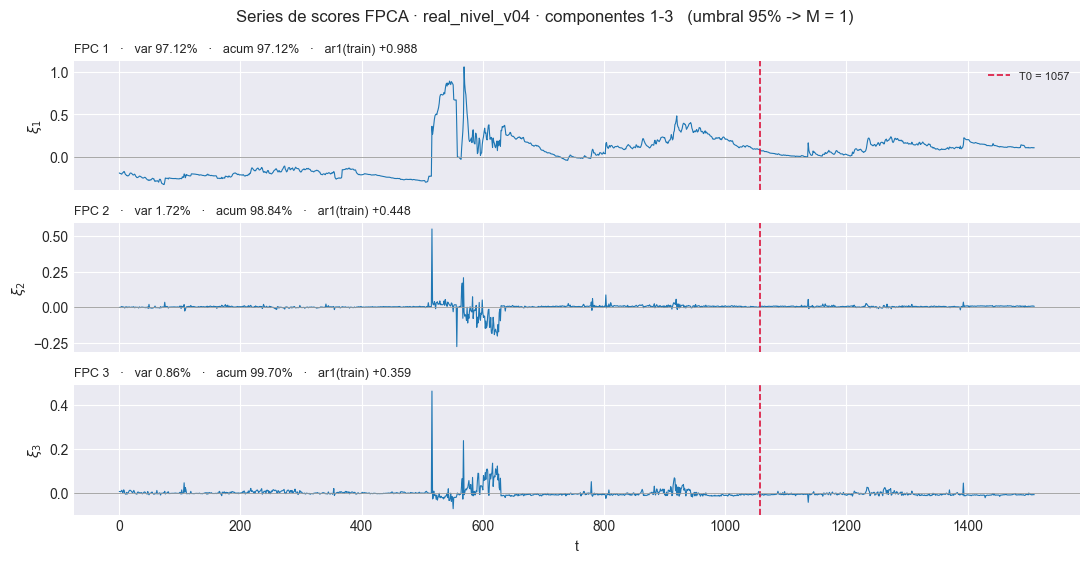

componentes graficadas : 1-3  de K = 18   <- DIFIERE del umbral (M_SUGERIDO = 1)
var. acumulada hasta 3 : 99.7007%


In [23]:
# [CONFIG] §3.4 — hasta que componente se grafica. Por defecto, la que fija el
# umbral VAR_TARGET de la celda anterior; subirlo mira mas alla de la regla.
N_SERIES_SCORES = max(M_FPCA_LIST)     # todas las que entran al barrido

assert 1 <= N_SERIES_SCORES <= K, f"N_SERIES_SCORES={N_SERIES_SCORES} fuera de [1, {K}]."

# B_full y no B: no depende de set_M. Serie completa, no solo train.
XI = (THETA - fpca.mu_theta) @ (fpca.W @ fpca.B_full)      # (T, K)

fig, axes = plt.subplots(N_SERIES_SCORES, 1, sharex=True,
                         figsize=(11, 1.9 * N_SERIES_SCORES))
axes = np.atleast_1d(axes)
for k, ax in enumerate(axes):
    ax.plot(np.arange(T), XI[:, k], lw=0.8, color="C0")
    ax.axvline(T0, color="crimson", ls="--", lw=1.2)
    ax.axhline(0, color="0.6", lw=0.6)
    ax.set_ylabel(rf"$\xi_{{{k+1}}}$")
    ax.set_title(f"FPC {k+1}   ·   var {fpca.var_ratio[k]:.2%}   ·   "
                 f"acum {fpca.var_cum[k]:.2%}   ·   ar1(train) {ar1[k]:+.3f}",
                 fontsize=9, loc="left")
axes[-1].set_xlabel("t")
axes[0].plot([], [], color="crimson", ls="--", lw=1.2, label=f"T0 = {T0}")
axes[0].legend(loc="upper right", fontsize=8)

fig.suptitle(f"Series de scores FPCA · {EXPERIMENT_BASE} · componentes 1-"
             f"{N_SERIES_SCORES}   (umbral {VAR_TARGET:.0%} -> M = {M_SUGERIDO})")
fig.tight_layout()
replicar_figura("07b_fpca_scores_series.png", PATHS_POR_M)
plt.show()

print(f"componentes graficadas : 1-{N_SERIES_SCORES}  de K = {K}"
      + ("" if N_SERIES_SCORES == M_SUGERIDO
         else f"   <- DIFIERE del umbral (M_SUGERIDO = {M_SUGERIDO})"))
print(f"var. acumulada hasta {N_SERIES_SCORES} : {fpca.var_cum[N_SERIES_SCORES-1]:.4%}")


### 3.5 Componentes estandarizados — sólo contraste

Los scores **no** se estandarizan: a MATLAB van los de §3.4, en su escala propia. Esta sección muestra lo que se descartó, no lo que se entrega.

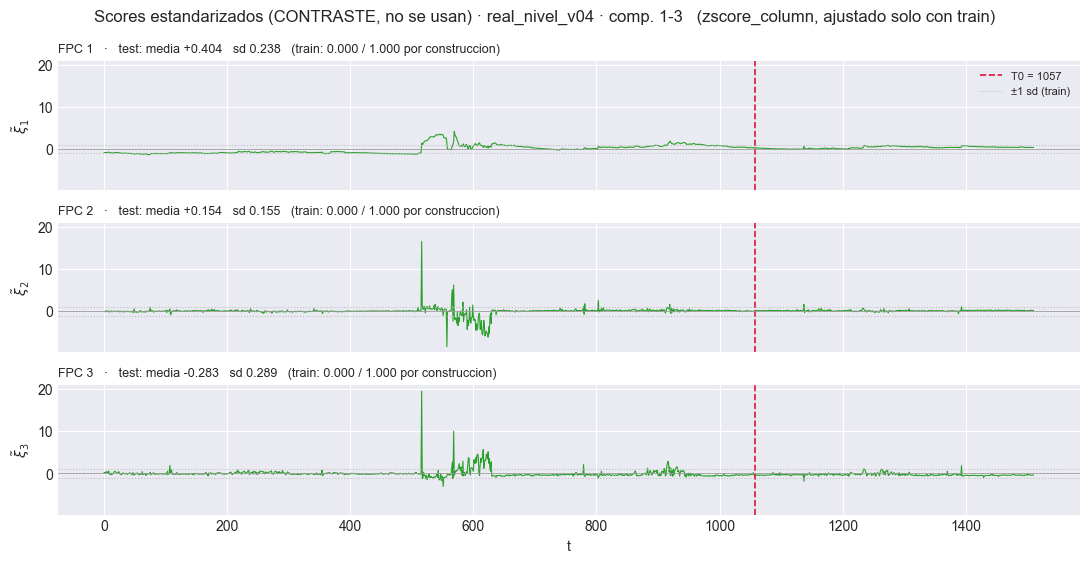

escala original  sd(train) : [0.2511 0.0334 0.0237]
estandarizado    sd(test)  : [0.2379 0.155  0.2887]    <- lejos de 1 = el bloque de prueba no comparte escala con train


In [24]:

_std = DataStandardizer(method="zscore_column", ddof=0)
_std.fit(XI[idx_train, :N_SERIES_SCORES], etiqueta=f"train[1:{T0}]")
XI_STD = _std.transform(XI[:, :N_SERIES_SCORES])            # (T, N_SERIES_SCORES)

fig, axes = plt.subplots(N_SERIES_SCORES, 1, sharex=True, sharey=True,
                         figsize=(11, 1.9 * N_SERIES_SCORES))
axes = np.atleast_1d(axes)
for k, ax in enumerate(axes):
    ax.plot(np.arange(T), XI_STD[:, k], lw=0.8, color="C2")
    ax.axvline(T0, color="crimson", ls="--", lw=1.2)
    ax.axhline(0, color="0.6", lw=0.6)
    for _s in (-1, 1):
        ax.axhline(_s, color="0.75", ls=":", lw=0.8)
    ax.set_ylabel(rf"$\tilde\xi_{{{k+1}}}$")
    ax.set_title(f"FPC {k+1}   ·   test: media {XI_STD[idx_test, k].mean():+.3f}   "
                 f"sd {XI_STD[idx_test, k].std():.3f}   "
                 f"(train: 0.000 / 1.000 por construccion)",
                 fontsize=9, loc="left")
axes[-1].set_xlabel("t")
axes[0].plot([], [], color="crimson", ls="--", lw=1.2, label=f"T0 = {T0}")
axes[0].plot([], [], color="0.75", ls=":", lw=0.8, label="±1 sd (train)")
axes[0].legend(loc="upper right", fontsize=8)

fig.suptitle(f"Scores estandarizados (CONTRASTE, no se usan) · {EXPERIMENT_BASE} · comp. 1-"
             f"{N_SERIES_SCORES}   (zscore_column, ajustado solo con train)")
fig.tight_layout()
plt.show()

print(f"escala original  sd(train) : "
      f"{np.array2string(XI[idx_train, :N_SERIES_SCORES].std(0), precision=4)}")
print(f"estandarizado    sd(test)  : "
      f"{np.array2string(XI_STD[idx_test].std(0), precision=4)}"
      "    <- lejos de 1 = el bloque de prueba no comparte escala con train")


## 4. El bucle sobre `M_FPCA_LIST`

Se realiza:
- §4.1:`set_M(M)` y scores; contraste con la regla del 95 % 
- §4.2: estandarizador en **identidad** (los scores van crudos) y artefactos FPCA 
- §4.3: diagnóstico de rezagos sobre el bloque de entrenamiento
- §4.4: orden AR y construcción de los datasets
- §4.5: hiperparámetros y `mcmc_config` — el contrato con MATLAB
- §4.6: `eval_config`, líneas base y `verificar_contrato` 


In [25]:
def procesar_punto(M: int) -> dict:
    """Produce TODOS los artefactos del punto M del barrido y verifica su contrato.

    Recibe por clausura los objetos comunes de §2-§3.3 —`fpca` ya ajustado,
    `THETA`, `idx_train`/`idx_test`, `grilla`, `X_raw`— y no los recalcula:
    ésa es la garantía de que los puntos comparten datos y base.
    """
    PATHS = PATHS_POR_M[M]
    eid = eid_de(M)
    print(f"\n{'='*70}\nM = {M}   ·   {eid}\n{'='*70}")

    # -- §4.1 Componentes retenidas ------------------------------------------
    assert 1 <= M <= fpca.evals.size, f"M fuera de [1, {fpca.evals.size}]."
    coincide_regla = (M == M_SUGERIDO)
    print(f"M(95 %) según la regla : {M_SUGERIDO}   (K disponible = {fpca.evals.size})")
    print(f"M de este punto        : {M}"
          + ("   (coincide con la regla)" if coincide_regla
             else "   <- DIFIERE de la regla: es un punto de sensibilidad"))

    fpca.set_M(int(M))
    M_fpca = fpca.M

    SCORES       = fpca.transform(THETA)       # (T, M) — base ajustada en train
    SCORES_train = SCORES[idx_train]
    SCORES_test  = SCORES[idx_test]

    print(f"M = {M_fpca}   var. explicada = {fpca.var_cum[M_fpca-1]:.4%}")
    print(f"[train] max|media xi| = {np.abs(SCORES_train.mean(0)).max():.2e}   (~ 0)")
    print(f"[test]  max|media xi| = {np.abs(SCORES_test.mean(0)).max():.3f}")
    print(f"[test]  var xi / lambda = "
          f"{np.array2string(SCORES_test.var(0, ddof=1) / fpca.lambdas, precision=3)}")

    # -- §4.2 Escala de los scores: SIN estandarizar --------------------------
    # Se ajusta con train y se registra n_ajuste igual, porque verificar_contrato
    # exige n_ajuste == T0. Lo que NO se hace es aplicarlo: ver abajo.
    scores_standardizer = DataStandardizer(method="zscore_column", ddof=0)
    scores_standardizer.fit(SCORES_train, etiqueta=f"train[1:{T0}]")

    _chk = scores_standardizer.verificar_ajuste(T0)
    print(f"[holdout] ajustado con {_chk['n_ajuste']} filas = T0 "
          f"({_chk['etiqueta_ajuste']}) -> ok={_chk['ajuste_ok']}")

    # SIN ESTANDARIZAR MATLAB recibe los scores en su ESCALA PROPIA. El objeto
    # no se elimina
    MU_OBS = scores_standardizer.mean.copy()
    SD_OBS = scores_standardizer.std.copy()
    scores_standardizer.mean = np.zeros_like(MU_OBS)
    scores_standardizer.std  = np.ones_like(SD_OBS)

    SCORES_STD       = scores_standardizer.transform(SCORES)
    assert np.allclose(SCORES_STD, SCORES), "la transformacion deberia ser la identidad."
    SCORES_STD_train = SCORES_STD[idx_train]
    SCORES_STD_test  = SCORES_STD[idx_test]

    print(f"\nSCORES_STD {SCORES_STD.shape}   (= SCORES: transformacion identidad)")
    print(f"  [train] media = {np.array2string(MU_OBS, precision=3)}   <- NO se resta")
    print(f"  [train] std   = {np.array2string(SD_OBS, precision=3)}   <- NO se divide")
    print(f"  [test]  media = {np.array2string(SCORES_STD_test.mean(0), precision=3)}")
    print(f"  [test]  std   = {np.array2string(SCORES_STD_test.std(0),  precision=3)}")
    print(f"  rango que vera MATLAB: [{SCORES_STD.min():.3f}, {SCORES_STD.max():.3f}]"
          "   <- de ahi sale la grilla G* y con ella la escala del gating")

    guardar_estandarizador(PATHS, scores_standardizer)
    _res = guardar_fpca(PATHS, fpca, SCORES, SCORES_STD=SCORES_STD,
                        meta_extra={"T0": int(T0)})
    print(f"\n[functional] artefactos FPCA · cond_W = {_res['meta']['cond_W']:.3e}")

    plot_diagnostico_estandarizacion(
        SCORES_train, SCORES_STD_train, np.arange(1, M_fpca + 1),
        labels=("Scores xi (escala lambda)", "Scores xi entregados (identicos: no se estandariza)"),
        title=f"estadísticas por componente FPCA (M={M})",
        save_path=str(PATHS["out_report"] / "08_diagnostico_estandarizacion.png"))
    plt.show()

    # -- §4.3 Diagnóstico de rezagos (sólo train) ----------------------------
    N_LAGS_MAX = 3
    T_theta, K_total = SCORES_STD_train.shape

    def _spearman(Y, Xm):
        """Spearman columna a columna vía rangos (pandas, sin scipy)."""
        Yc = pd.DataFrame(Y).rank().to_numpy(); Yc = Yc - Yc.mean(0)
        Xc = pd.DataFrame(Xm).rank().to_numpy(); Xc = Xc - Xc.mean(0)
        return (Yc.T @ Xc) / np.outer(np.sqrt((Yc**2).sum(0)), np.sqrt((Xc**2).sum(0)))

    corr_p = np.zeros((K_total, K_total * N_LAGS_MAX))
    corr_s = np.zeros_like(corr_p)
    col_labels = []
    y_block = SCORES_STD_train[N_LAGS_MAX:, :]

    for lag in range(1, N_LAGS_MAX + 1):
        x_block = SCORES_STD_train[N_LAGS_MAX - lag : T_theta - lag, :]
        sp = _spearman(y_block, x_block)
        for j in range(K_total):
            c = (lag - 1) * K_total + j
            for k in range(K_total):
                corr_p[k, c] = np.corrcoef(y_block[:, k], x_block[:, j])[0, 1]
            corr_s[:, c] = sp[:, j]
            col_labels.append(rf"$\xi_{{t-{lag},{j+1}}}$")

    row_labels = [rf"$\xi_{{t,{k+1}}}$" for k in range(K_total)]
    band = 1.96 / np.sqrt(len(y_block))

    for M_corr, nombre, arch in ((corr_p, "Pearson", "09a"), (corr_s, "Spearman", "09b")):
        plot_rezagos_heatmap(
            M_corr, col_labels, row_labels,
            title=f"{nombre} — respuesta($t$) vs rezagos 1..{N_LAGS_MAX}  (M={M})",
            n_lags_max=N_LAGS_MAX, K_total=K_total, band=band, vclip=0.6,
            save_path=str(PATHS["out_report"] / f"{arch}_rezagos_{nombre.lower()}.png"))
        plt.show()

    # -- §4.4 Orden AR y datasets --------------------------------------------
    COMPONENT_IDX = list(range(SCORES_STD.shape[1]))   # base-0; los nombres usan idx+1

    n_components = len(COMPONENT_IDX)
    n_train_eff  = T0 - N_LAGS
    n_test_eff   = T - T0

    assert T0 > N_LAGS and len(set(COMPONENT_IDX)) == n_components

    cov_names = [f"fpc_{COMPONENT_IDX[j] + 1}_lag{lag}"
                 for lag in range(1, N_LAGS + 1)
                 for j in range(n_components)]

    print(f"componentes : {n_components} -> índices {COMPONENT_IDX}")
    print(f"N_LAGS      : {N_LAGS}   ·   p = {len(cov_names)} covariables")
    print(f"n_train_eff : {n_train_eff}   n_test_eff : {n_test_eff}")
    print(f"cov_names   : {cov_names}")

    SCORES_sel = SCORES_STD[:, COMPONENT_IDX]

    def _dataset_bloque(k, t_ini, t_fin):
        """Respuesta en t en [t_ini, t_fin) y predictores en t-1 ... t-N_LAGS."""
        t_idx  = np.arange(t_ini, t_fin)
        X_cols = np.hstack([SCORES_sel[t_idx - lag, :] for lag in range(1, N_LAGS + 1)])
        return pd.DataFrame(np.column_stack([SCORES_sel[t_idx, k], X_cols]),
                            columns=[f"fpc_{COMPONENT_IDX[k] + 1}"] + cov_names)

    dfs_train = {k: _dataset_bloque(k, N_LAGS, T0) for k in range(n_components)}
    dfs_test  = {k: _dataset_bloque(k, T0,     T)  for k in range(n_components)}

    manifest = {
        "scores_scale":  "raw_fpca_scores",
        "n_components":  n_components,
        "n_lags":        int(N_LAGS),
        "component_idx": [int(i) for i in COMPONENT_IDX],
        "cov_names":     cov_names,
        "T": int(T), "T0": int(T0), "prop_train": float(PROP_TRAIN),
        "n_train_eff": int(n_train_eff), "n_test_eff": int(n_test_eff),
        "ajuste_en": "train",
    }
    guardar_datasets_ar(PATHS, dfs_train, dfs_test, manifest)
    print(f"[functional] {2*n_components} datasets + datasets_manifest.json")
    for k in range(n_components):
        print(f"  fpc_{COMPONENT_IDX[k]+1}: train {dfs_train[k].shape} · test {dfs_test[k].shape}")

    # -- §4.5 Hiperparámetros y MCMC
    # Escala del argumento probit. v_h(x) = Phi(alpha_h - sum_j psi_hj |x_j - Gamma_hj|)
    # crece LINEALMENTE en p y con la amplitud de G*, de modo que con los scores
    # SIN estandarizar mupsij no se puede fijar a mano: se despeja de
    # arg_objetivo. Se replica la grilla G* de psbp_train.m (min/max GLOBALES de
    # Xnoint, no por columna) y el sorteo de Gammajh sobre ella.
    _Xn      = np.vstack([dfs_train[k][cov_names].to_numpy() for k in range(n_components)])
    _lo, _hi = float(_Xn.min()), float(_Xn.max())
    _Gstar   = _lo + (np.arange(1, MCMC_CONFIG["M"] + 1) / MCMC_CONFIG["M"]) * (_hi - _lo)
    _rng_cal = np.random.default_rng(SEED)
    _Gam     = _rng_cal.choice(_Gstar, size=(MCMC_CONFIG["N"] - 1, len(cov_names)))
    ESCALA_PROBIT = float(np.abs(_Xn[None, :, :] - _Gam[:, None, :]).sum(-1).mean())

    print(f"\nG* = [{_lo:.3f}, {_hi:.3f}]   E[sum_j |x_j - Gamma_j|] = {ESCALA_PROBIT:.3f}")

    def _clasificar(nombre, k_modelo):
        return ("own_lag1" if nombre == f"fpc_{COMPONENT_IDX[k_modelo] + 1}_lag1"
                else "cross_lag")

    # apij/bpij salen de HP_BY_TYPE, no de la escalera: lo que los ordena es el
    # TIPO de rezago, no k. Lo demas de la escalera sigue siendo por componente.
    def _beta_pi(nombre, k_modelo):
        cfg = HP_BY_TYPE[_clasificar(nombre, k_modelo)]
        return float(cfg["apij"]), float(cfg["bpij"])

    # Tasa de escape del estado w_j = 0

    def _escape(apij, bpij, pwj, N):
        b_val = math.exp(math.lgamma(bpij + N) + math.lgamma(apij + bpij)
                         - math.lgamma(bpij) - math.lgamma(apij + bpij + N))
        return pwj * b_val / ((1 - pwj) + pwj * b_val)

    HYPERPARAMS_LIST = []
    for k in range(n_components):
        esc      = HP_ESCALERA[k]
        mupsij_k = esc["arg_objetivo"] / ESCALA_PROBIT
        _ab      = [_beta_pi(nm, k) for nm in cov_names]


        var_y_k = float(SCORES_train[:, k].var(ddof=0))
        E_tau_k = float(esc["e_tau_rel"]) / var_y_k     # E[tau] * var(y_k) = e_tau_rel
        btau_k  = esc["atau"] / E_tau_k

        HYPERPARAMS_LIST.append({**HP_GLOBAL,
            "atau": float(esc["atau"]), "btau": float(btau_k),
            "apij":    np.array([a for a, _ in _ab], dtype=float),
            "bpij":    np.array([b for _, b in _ab], dtype=float),
            "mupsij":  np.full(len(cov_names), mupsij_k,       dtype=float),
            "taupsij": np.full(len(cov_names), esc["taupsij"], dtype=float)})

    print(f"\nN_CHAINS = {N_CHAINS} cadenas por componente "
          f"-> {N_CHAINS * n_components} jobs en MATLAB para este M")
    print(f"  {'k':>2} {'fpc':>4} {'arg':>6} {'mupsij':>9} {'taupsij':>8} "
          f"{'Etau*var':>9} {'var(y)':>8} {'1/var':>7} {'E[tau]':>8} {'btau':>8}")
    for k in range(n_components):
        hp, esc = HYPERPARAMS_LIST[k], HP_ESCALERA[k]
        _v = float(SCORES_train[:, k].var(ddof=0))
        print(f"  {k:>2} {COMPONENT_IDX[k]+1:>4} {esc['arg_objetivo']:>6.2f} "
              f"{hp['mupsij'][0]:>9.5f} {hp['taupsij'][0]:>8.1f} "
              f"{esc['e_tau_rel']:>9.2f} {_v:>8.4f} {1/_v:>7.2f} "
              f"{hp['atau']/hp['btau']:>8.2f} {hp['btau']:>8.5f}")

    # apij/bpij por covariable + la espera esperada para que w_j vuelva de 0.
    print(f"\n  {'k':>2} {'covariable':>16} {'tipo':>10} {'apij':>6} {'bpij':>6} "
          f"{'E[pi]':>7} {'P(escape)':>10} {'espera':>8}")
    for k in range(n_components):
        hp = HYPERPARAMS_LIST[k]
        for j, nm in enumerate(cov_names):
            a, b = hp["apij"][j], hp["bpij"][j]
            pe   = _escape(a, b, HP_GLOBAL["pwj"], MCMC_CONFIG["N"])
            flag = "  <- > nsim" if 1 / pe > MCMC_CONFIG["nsim"] else ""
            print(f"  {k:>2} {nm:>16} {_clasificar(nm, k):>10} {a:>6.3f} {b:>6.3f} "
                  f"{a/(a+b):>7.3f} {pe:>10.2e} {1/pe:>8.0f}{flag}")

    hp_artifact = {
        "global":       HP_GLOBAL,
        "by_type":      HP_BY_TYPE,
        "escalera":     {str(k): HP_ESCALERA[k] for k in range(n_components)},
        "escala_probit": ESCALA_PROBIT,
        "mcmc_config":  MCMC_CONFIG,
        "n_iter":       N_CHAINS,
        "seed_scheme":  "seed_base + chain*9973 + k*31",
        "serie_id":     SERIE_ID,
        "ventana_id":   int(VENTANA_ID),
        "m_fpca":       int(M),
        "seed_base":    int(SEED),     # MATLAB la lee de aquí (ya no está hardcodeada)
        "scores_scale": "raw_fpca_scores",
        "partition": {
            "T": int(T), "T0": int(T0), "prop_train": float(PROP_TRAIN),
            "n_train_eff": int(n_train_eff), "n_test_eff": int(n_test_eff),
            "train_files": [f"dataset_fpc_{COMPONENT_IDX[k]+1}_train.csv"
                            for k in range(n_components)],
            "test_files":  [f"dataset_fpc_{COMPONENT_IDX[k]+1}_test.csv"
                            for k in range(n_components)],
        },
        "hyperparams_list": [
            {"component_k": k, "fpc_idx": int(COMPONENT_IDX[k] + 1),
             "hyperparams": {key: (v.tolist() if isinstance(v, np.ndarray) else v)
                             for key, v in HYPERPARAMS_LIST[k].items()}}
            for k in range(n_components)
        ],
    }
    guardar_hiperparametros(PATHS, hp_artifact)
    print(f"[out_artefact] hyperparameters.json -> {PATHS['out_artefact']}")

    # -- §4.6 Evaluación, líneas base y contrato -----------------------------
    eval_config = {
        "scheme":      "holdout_temporal",
        "T": int(T), "T0": int(T0), "prop_train": float(PROP_TRAIN),
        "horizons":    [1],
        "n_lags":      int(N_LAGS),
        "m_fpca":      int(M),
        "scores_scale": "raw_fpca_scores",
        "fuente":              "datos observados (estación hidrológica)",
        "variable":            VARIABLE,
        "objetivo_evaluacion": "curva_observada",
        "modo_residuo":        "empirico",
        "nivel_credibilidad":  0.95,
        "ventana_movil": {"w": [10, 20, 40], "paso": 1, "solapadas": True},
        # Las metricas del marco teorico 02_02_03, y solo esas.
        "metricas_bloque_A": ["mae_f", "rmse_f", "linf_medio", "linf_max"],
        "metricas_bloque_B": ["mpiw", "picp", "picp_simultaneo", "winkler",
                              "winkler_max_medio", "winkler_max_glob"],
    }
    guardar_config_evaluacion(PATHS, eval_config)
    print("[out_artefact] eval_config.json")

    # Líneas base a h=1: el piso que el PSBP-FD debe superar.
    baselines_df = tabla_baselines(SCORES_STD, T0, estandarizador=scores_standardizer,
                                   fpca=fpca, X_obs=X_raw, tau=grilla, h=1)
    baselines_df.to_csv(PATHS["out_report"] / "30_baselines_test.csv")
    display(baselines_df.style.format("{:.4f}", na_rep="-")
            .set_caption(f"Líneas base (M={M}) — prueba, h=1, contra la curva OBSERVADA"))

    informe = verificar_contrato(PATHS)
    print(f"contrato_ok = {informe['contrato_ok']}   "
          f"(M={informe['M']}, K={informe['K']}, T0={informe['T0']}, "
          f"n_components={informe['n_components']})")
    print(f"estandarizador ajustado con {informe.get('estandarizador_n_ajuste')} filas "
          f"(T0={informe['T0']})")
    print(f"verificación FPCA: todo_ok = {informe['verificacion_fpca']['todo_ok']}")
    if not informe["contrato_ok"]:
        print("\nPROBLEMAS:")
        for p in informe.get("problemas", []):
            print(f"  - {p}")

    return {
        "M": int(M),
        "experiment_id": eid,
        "var_acum": float(fpca.var_cum[M_fpca - 1]),
        "K": int(fpca.evals.size),
        "coincide_regla_95": bool(coincide_regla),
        "n_components": int(n_components),
        "p_covariables": int(len(cov_names)),
        "contrato_ok": bool(informe["contrato_ok"]),
        "problemas": informe.get("problemas", []),
    }


escalera por componente (btau se despeja en procesar_punto):
   k    arg  taupsij   atau  E[tau]*var
   0   2.00      0.5   2.50        2.00
   1   1.50      1.0   2.00        2.00
   2   1.00      2.0   1.50        2.00

inclusion por tipo (apij/bpij ya no son de la escalera):
    own_lag1  apij=1.0000  bpij=0.1111  E[pi]=0.900
   cross_lag  apij=1.0000  bpij=5.0000  E[pi]=0.167
N_LAGS      : 1
MCMC_CONFIG : {'nsim': 3000, 'burn': 3000, 'N': 70, 'M': 70}   (su 'M' es la grilla G* del stick-breaking)
N_CHAINS    : 2
Draws posteriores por score: (3000 - 3000) x 2 = 0

M = 1   ·   real_nivel_v04_m01
M(95 %) según la regla : 1   (K disponible = 18)
M de este punto        : 1   (coincide con la regla)
M = 1   var. explicada = 97.1209%
[train] max|media xi| = 1.08e-16   (~ 0)
[test]  max|media xi| = 0.101
[test]  var xi / lambda = [0.057]
[holdout] ajustado con 1057 filas = T0 (train[1:1057]) -> ok=True

SCORES_STD (1511, 1)   (= SCORES: transformacion identidad)
  [train] media = [1.076e-

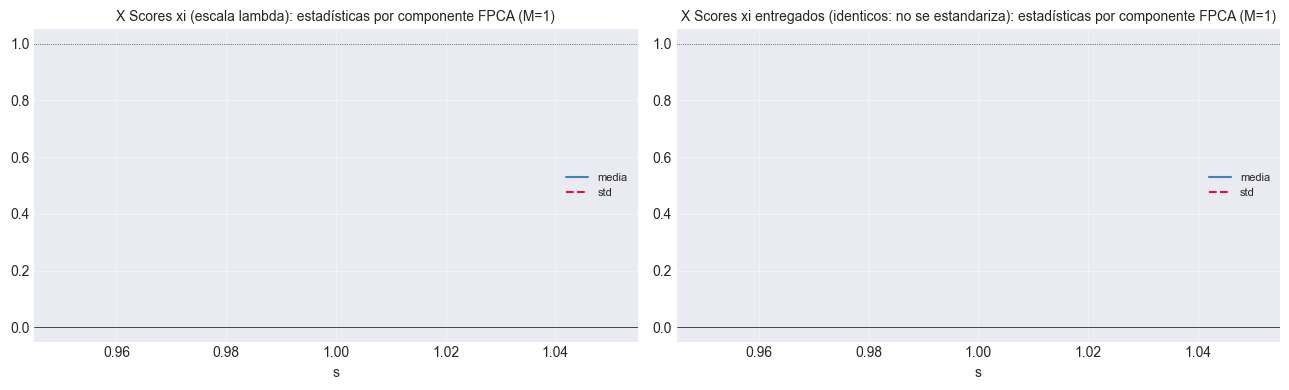

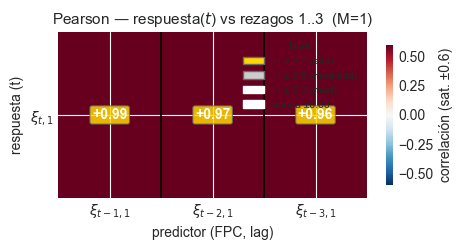

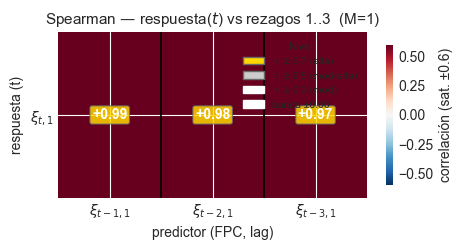

componentes : 1 -> índices [0]
N_LAGS      : 1   ·   p = 1 covariables
n_train_eff : 1056   n_test_eff : 454
cov_names   : ['fpc_1_lag1']
[functional] 2 datasets + datasets_manifest.json
  fpc_1: train (1056, 2) · test (454, 2)

G* = [-0.326, 1.061]   E[sum_j |x_j - Gamma_j|] = 0.597

N_CHAINS = 2 cadenas por componente -> 2 jobs en MATLAB para este M
   k  fpc    arg    mupsij  taupsij  Etau*var   var(y)   1/var   E[tau]     btau
   0    1   2.00   3.35070      0.5      2.00   0.0631   15.86    31.72  0.07882

   k       covariable       tipo   apij   bpij   E[pi]  P(escape)   espera
   0       fpc_1_lag1   own_lag1  1.000  0.111   0.900   1.58e-03      632
[out_artefact] hyperparameters.json -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\artefact\reales\real_nivel_v04_m01
[out_artefact] eval_config.json


,n_test,RMSE_fpc1,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,
media_incondicional,454.0000,0.1178,0.1178,-2.8848,0.0141,0.1189
persistencia_lag1,454.0000,0.0134,0.0134,0.9499,0.0004,0.0210


contrato_ok = True   (M=1, K=18, T0=1057, n_components=1)
estandarizador ajustado con 1057 filas (T0=1057)
verificación FPCA: todo_ok = True

M = 2   ·   real_nivel_v04_m02
M(95 %) según la regla : 1   (K disponible = 18)
M de este punto        : 2   <- DIFIERE de la regla: es un punto de sensibilidad
M = 2   var. explicada = 98.8368%
[train] max|media xi| = 2.83e-16   (~ 0)
[test]  max|media xi| = 0.101
[test]  var xi / lambda = [0.057 0.024]
[holdout] ajustado con 1057 filas = T0 (train[1:1057]) -> ok=True

SCORES_STD (1511, 2)   (= SCORES: transformacion identidad)
  [train] media = [5.386e-17 2.828e-16]   <- NO se resta
  [train] std   = [0.251 0.033]   <- NO se divide
  [test]  media = [0.101 0.005]
  [test]  std   = [0.06  0.005]
  rango que vera MATLAB: [-0.326, 1.061]   <- de ahi sale la grilla G* y con ella la escala del gating

[functional] artefactos FPCA · cond_W = 2.199e+01


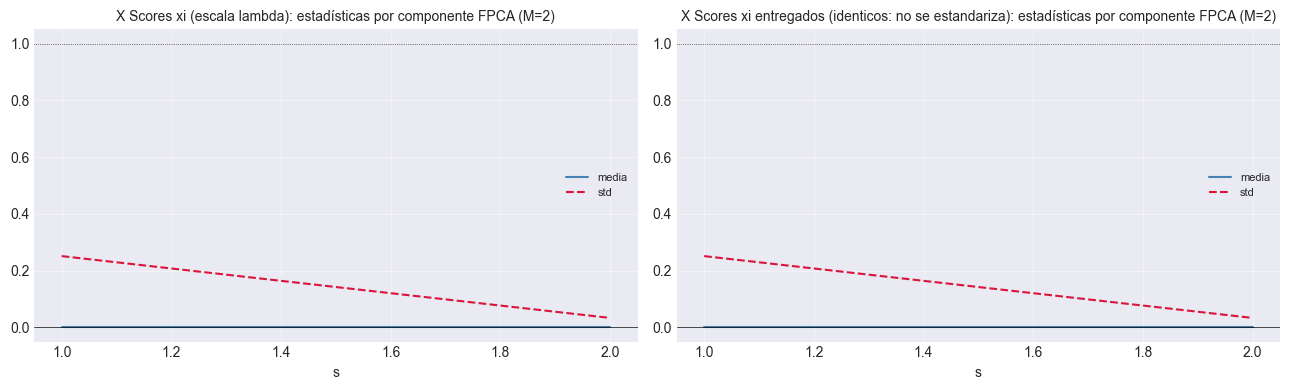

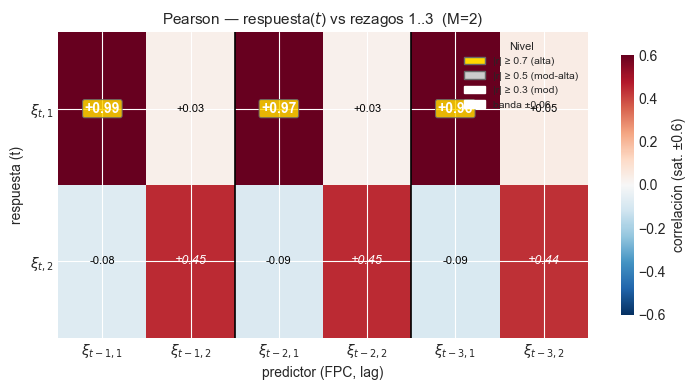

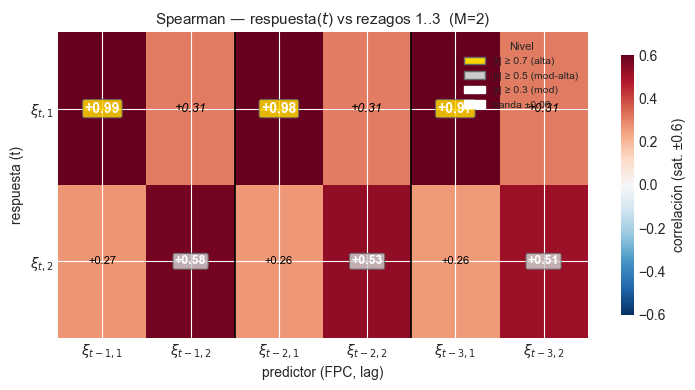

componentes : 2 -> índices [0, 1]
N_LAGS      : 1   ·   p = 2 covariables
n_train_eff : 1056   n_test_eff : 454
cov_names   : ['fpc_1_lag1', 'fpc_2_lag1']
[functional] 4 datasets + datasets_manifest.json
  fpc_1: train (1056, 3) · test (454, 3)
  fpc_2: train (1056, 3) · test (454, 3)

G* = [-0.326, 1.061]   E[sum_j |x_j - Gamma_j|] = 1.064

N_CHAINS = 2 cadenas por componente -> 4 jobs en MATLAB para este M
   k  fpc    arg    mupsij  taupsij  Etau*var   var(y)   1/var   E[tau]     btau
   0    1   2.00   1.87956      0.5      2.00   0.0631   15.86    31.72  0.07882
   1    2   1.50   1.40967      1.0      2.00   0.0011  897.64  1795.28  0.00111

   k       covariable       tipo   apij   bpij   E[pi]  P(escape)   espera
   0       fpc_1_lag1   own_lag1  1.000  0.111   0.900   1.58e-03      632
   0       fpc_2_lag1  cross_lag  1.000  5.000   0.167   6.25e-02       16
   1       fpc_1_lag1  cross_lag  1.000  5.000   0.167   6.25e-02       16
   1       fpc_2_lag1   own_lag1  1.000  0.1

,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,
media_incondicional,454.0000,0.1178,0.0073,0.0625,-1.9383,0.0141,0.1189
persistencia_lag1,454.0000,0.0134,0.0063,0.0099,0.2276,0.0004,0.0207


contrato_ok = True   (M=2, K=18, T0=1057, n_components=2)
estandarizador ajustado con 1057 filas (T0=1057)
verificación FPCA: todo_ok = True

M = 3   ·   real_nivel_v04_m03
M(95 %) según la regla : 1   (K disponible = 18)
M de este punto        : 3   <- DIFIERE de la regla: es un punto de sensibilidad
M = 3   var. explicada = 99.7007%
[train] max|media xi| = 2.83e-16   (~ 0)
[test]  max|media xi| = 0.101
[test]  var xi / lambda = [0.057 0.024 0.083]
[holdout] ajustado con 1057 filas = T0 (train[1:1057]) -> ok=True

SCORES_STD (1511, 3)   (= SCORES: transformacion identidad)
  [train] media = [ 5.386e-17  2.828e-16 -8.680e-17]   <- NO se resta
  [train] std   = [0.251 0.033 0.024]   <- NO se divide
  [test]  media = [ 0.101  0.005 -0.007]
  [test]  std   = [0.06  0.005 0.007]
  rango que vera MATLAB: [-0.326, 1.061]   <- de ahi sale la grilla G* y con ella la escala del gating

[functional] artefactos FPCA · cond_W = 2.199e+01


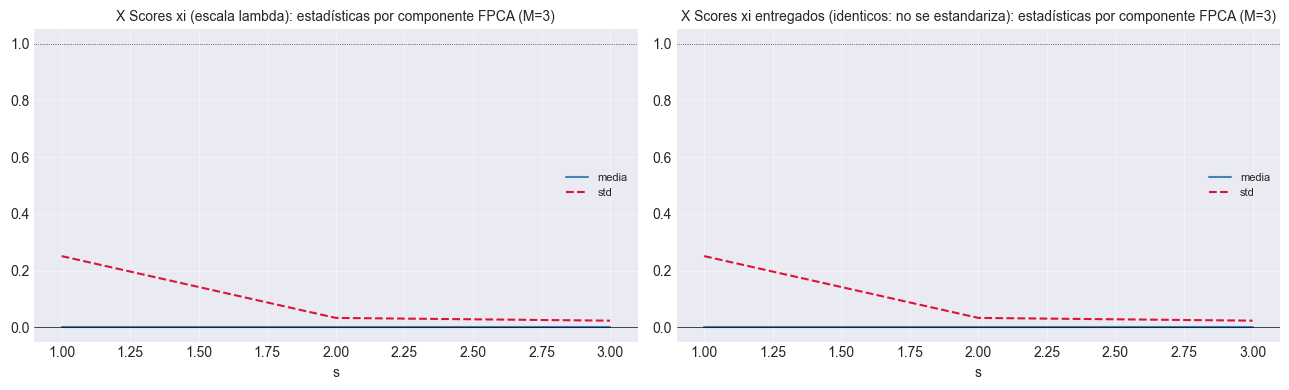

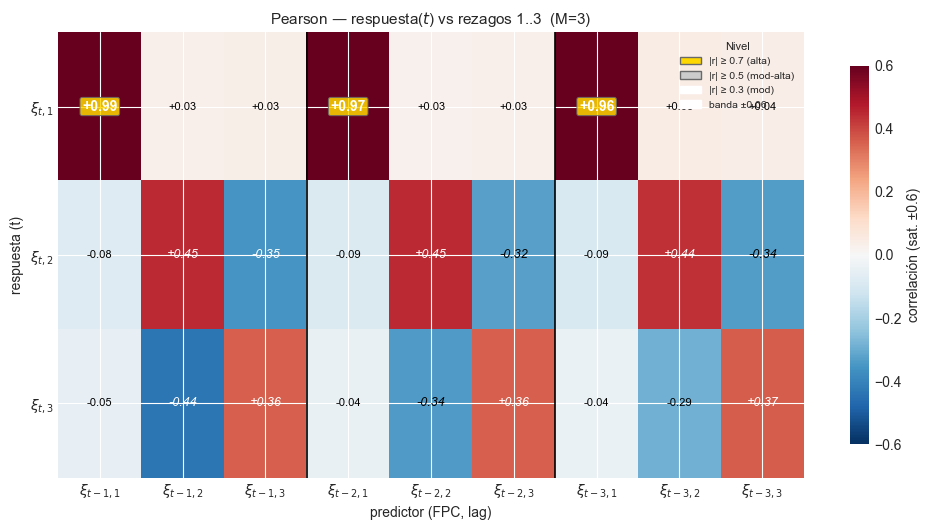

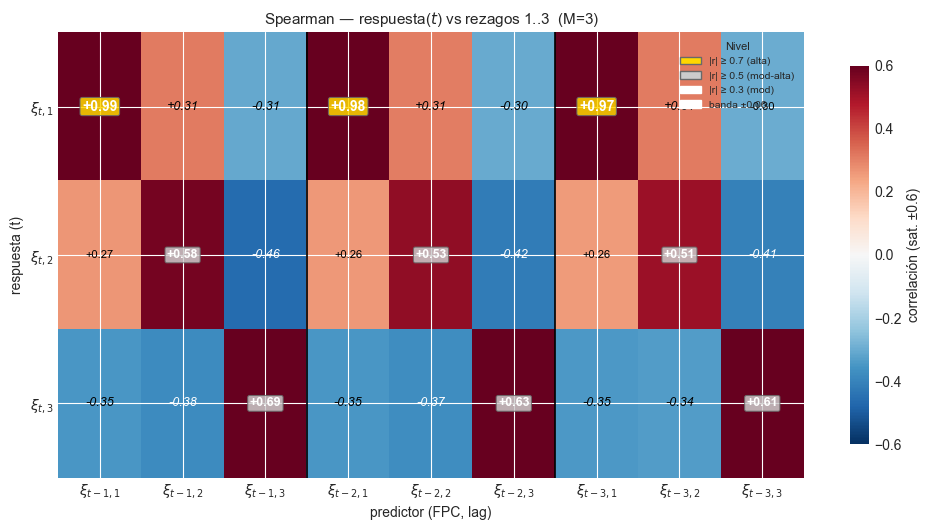

componentes : 3 -> índices [0, 1, 2]
N_LAGS      : 1   ·   p = 3 covariables
n_train_eff : 1056   n_test_eff : 454
cov_names   : ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1']
[functional] 6 datasets + datasets_manifest.json
  fpc_1: train (1056, 4) · test (454, 4)
  fpc_2: train (1056, 4) · test (454, 4)
  fpc_3: train (1056, 4) · test (454, 4)

G* = [-0.326, 1.061]   E[sum_j |x_j - Gamma_j|] = 1.575

N_CHAINS = 2 cadenas por componente -> 6 jobs en MATLAB para este M
   k  fpc    arg    mupsij  taupsij  Etau*var   var(y)   1/var   E[tau]     btau
   0    1   2.00   1.26977      0.5      2.00   0.0631   15.86    31.72  0.07882
   1    2   1.50   0.95233      1.0      2.00   0.0011  897.64  1795.28  0.00111
   2    3   1.00   0.63489      2.0      2.00   0.0006 1783.02  3566.04  0.00042

   k       covariable       tipo   apij   bpij   E[pi]  P(escape)   espera
   0       fpc_1_lag1   own_lag1  1.000  0.111   0.900   1.58e-03      632
   0       fpc_2_lag1  cross_lag  1.000  5.000   0.167 

,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_fpc3,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,,
media_incondicional,454.0000,0.1178,0.0073,0.0096,0.0449,-1.6117,0.0141,0.1189
persistencia_lag1,454.0000,0.0134,0.0063,0.0068,0.0088,0.1564,0.0004,0.0195


contrato_ok = True   (M=3, K=18, T0=1057, n_components=3)
estandarizador ajustado con 1057 filas (T0=1057)
verificación FPCA: todo_ok = True


In [26]:
# -- [CONFIG] Comunes a TODOS los puntos del barrido -------------------------
N_LAGS      = 1
MCMC_CONFIG = {"nsim": 3000, "burn": 3000, "N": 70, "M": 70}   # ojo: ese M es G*
N_CHAINS    = 2

# Priors globales
HP_GLOBAL = {"atau": 2.0, "btau": 0.5, "ag": 2.0, "bg": 0.5,
             "mumu": 0.0, "taumu": 1.0, "pwj": 0.5}

# Priors de INCLUSION por tipo de covariable. apij/bpij ya NO estan en la
# escalera: lo que los ordena es el tipo de rezago, no el componente k.
#
# apij = 1 en los dos por una razon de MEZCLA, no de encogimiento. w_j = 0 es un
# estado absorbente (ver la seccion w_j abajo) y la tasa de escape decae como
# N^(-apij). Con apij = 1 se cierra en forma:
#       E[pi] = 1/(1+bpij)          escape = bpij/(bpij+N)     [con pwj=0.5]
# o sea que E[pi] alto y escape rapido son OPUESTOS, y bpij elige el punto.
#
#   own_lag1   bpij=1/9 -> E[pi]=0.90, escape cada 316 iter. Lento a proposito:
#              el propio rezago no se quiere excluir nunca, y medido en 50_c
#              nunca se apago (flips=0 en las dos cadenas). Si igual cae, tarda.
#   cross_lag  bpij=5   -> E[pi]=0.167, escape cada 9 iter. Son los valores de
#              Chung & Dunson (references/Case1_01.m:35) y son los que se
#              apagaban y no volvian.
HP_BY_TYPE = {
    "own_lag1":  {"apij": 1.0, "bpij": 1.0 / 9.0},
    "cross_lag": {"apij": 1.0, "bpij": 5.0},
}


_ESCALON = [
    {"arg_objetivo": 2.0, "taupsij": 0.5, "atau": 2.5, "e_tau_rel": 2},
    {"arg_objetivo": 1.5, "taupsij": 1.0, "atau": 2.0, "e_tau_rel": 2},
    {"arg_objetivo": 1.0, "taupsij": 2.0, "atau": 1.5, "e_tau_rel": 2},
    {"arg_objetivo": 1.0, "taupsij": 2.0, "atau": 1.0, "e_tau_rel": 2},
]
HP_ESCALERA = {k: dict(_ESCALON[min(k, len(_ESCALON) - 1)])
               for k in range(max(M_FPCA_LIST))}

print("\nescalera por componente (btau se despeja en procesar_punto):")
print(f"  {'k':>2} {'arg':>6} {'taupsij':>8} {'atau':>6} {'E[tau]*var':>11}")
for _k in range(max(M_FPCA_LIST)):
    _e = HP_ESCALERA[_k]
    print(f"  {_k:>2} {_e['arg_objetivo']:>6.2f} {_e['taupsij']:>8.1f} "
          f"{_e['atau']:>6.2f} {_e['e_tau_rel']:>11.2f}")

print("")
print("inclusion por tipo (apij/bpij ya no son de la escalera):")
for _t, _c in HP_BY_TYPE.items():
    print(f"  {_t:>10}  apij={_c['apij']:.4f}  bpij={_c['bpij']:.4f}  "
          f"E[pi]={_c['apij']/(_c['apij']+_c['bpij']):.3f}")

print(f"N_LAGS      : {N_LAGS}")
print(f"MCMC_CONFIG : {MCMC_CONFIG}   (su 'M' es la grilla G* del stick-breaking)")
print(f"N_CHAINS    : {N_CHAINS}")
print(f"Draws posteriores por score: "
      f"({MCMC_CONFIG['nsim']} - {MCMC_CONFIG['burn']}) x {N_CHAINS} = "
      f"{(MCMC_CONFIG['nsim'] - MCMC_CONFIG['burn']) * N_CHAINS}")

RESUMEN = [procesar_punto(M) for M in M_FPCA_LIST]

## 5. Resumen del barrido

In [27]:
resumen_df = pd.DataFrame(RESUMEN).set_index("M")
display(resumen_df[["experiment_id", "var_acum", "K", "coincide_regla_95",
                    "n_components", "p_covariables", "contrato_ok"]]
        .style.format({"var_acum": "{:.4%}"})
        .set_caption(f"Barrido en M · {EXPERIMENT_BASE} · "
                     f"K disponible = {resumen_df['K'].iloc[0]}"))

_fallidos = [r for r in RESUMEN if not r["contrato_ok"]]
for r in _fallidos:
    print(f"\n[FALLA] M={r['M']} ({r['experiment_id']}):")
    for p in r["problemas"]:
        print(f"  - {p}")
assert not _fallidos, (
    f"El contrato falla en M = {[r['M'] for r in _fallidos]}. No lanzar MATLAB: "
    f"psbp_fd_iteracion.m leería artefactos inconsistentes.")

print(f"\n{'='*70}\nListo. Siguiente paso, en MATLAB desde esta carpeta:\n"
      f"  >> psbp_fd_iteracion\n"
      f"con M_FPCA_LIST = [{' '.join(str(m) for m in M_FPCA_LIST)}]  "
      f"(el mismo de 23_03, 23_04 y 23_05)\n{'='*70}")

,experiment_id,var_acum,K,coincide_regla_95,n_components,p_covariables,contrato_ok
M,,,,,,,
1,real_nivel_v04_m01,97.1209%,18,True,1,1,True
2,real_nivel_v04_m02,98.8368%,18,False,2,2,True
3,real_nivel_v04_m03,99.7007%,18,False,3,3,True



Listo. Siguiente paso, en MATLAB desde esta carpeta:
  >> psbp_fd_iteracion
con M_FPCA_LIST = [1 2 3]  (el mismo de 23_03, 23_04 y 23_05)
